# Pattern 6 — Agent

## The idea in one line
**Give the LLM a set of tools and let it decide, turn by turn, which tool to call until the task is done.**

## When to use it
When the problem is **open-ended** and the sequence of steps can't be predefined:

- "Answer this question using any of: web search, calculator, database lookup"
- "Fix this bug — you can read files, run tests, and edit files"
- "Book me a flight that works with my calendar"

The LLM is in charge of the control flow — that's what makes it an **agent** instead of a workflow.

## When *not* to use it
If you can write the path down as a flowchart (patterns 1–5), do that. Agents are harder to debug, slower, and more expensive. Only reach for this pattern when the flexibility is actually needed.

## The shape of the graph

![Agent loop](../images/agent.avif)


```
START ─► llm_call ──(tool_calls?)──► tool_node ─┐
            ▲                                    │
            └────────────────────────────────────┘
            (loop until no more tool calls)

          (no tool_calls) ─► END
```

Just **two nodes** — `llm_call` and `tool_node` — and a loop between them. The LLM keeps calling tools until it has enough info to answer directly; then it stops.

The state uses `MessagesState` (a built-in LangGraph state) — the conversation history lives in `state["messages"]` and each node appends to it.


In [1]:
# Setup — run this first in every notebook
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=1.0,
    max_retries=2,
    google_api_key=os.getenv("GEMINI_API_KEY"),
)


## Example 1 — The docs example (arithmetic agent)

Three tiny tools (`add`, `multiply`, `divide`). The agent decides which tool(s) to call to answer arithmetic questions.

Notice:
- `@tool` turns any Python function into something the LLM can call (the docstring becomes the tool description).
- `llm.bind_tools(tools)` tells the LLM those tools are available.
- `should_continue` is the routing logic: if the last message contains `tool_calls`, go execute them; otherwise we're done.


In [2]:
from typing_extensions import Literal
from langchain.tools import tool
from langchain.messages import SystemMessage, HumanMessage, ToolMessage
from langgraph.graph import MessagesState, StateGraph, START, END


@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`."""
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`."""
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`."""
    return a / b


tools = [add, multiply, divide]
tools_by_name = {t.name: t for t in tools}
llm_with_tools = llm.bind_tools(tools)


def llm_call(state: MessagesState):
    """LLM decides: answer directly, or call a tool."""
    return {
        "messages": [
            llm_with_tools.invoke(
                [SystemMessage(content="You are a helpful assistant tasked with arithmetic.")]
                + state["messages"]
            )
        ]
    }


def tool_node(state: dict):
    """Execute every tool call from the last LLM message."""
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_fn = tools_by_name[tool_call["name"]]
        observation = tool_fn.invoke(tool_call["args"])
        result.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))
    return {"messages": result}


def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    """Loop if the LLM asked for a tool, else finish."""
    last = state["messages"][-1]
    if last.tool_calls:
        return "tool_node"
    return END


agent_builder = StateGraph(MessagesState)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

graph = agent_builder.compile()


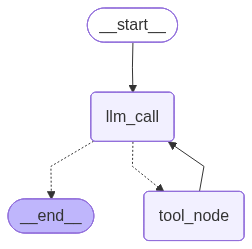

In [3]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [4]:
messages = [HumanMessage(content="Add 3 and 4, then multiply the result by 10.")]
result = graph.invoke({"messages": messages})

for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

Add 3 and 4, then multiply the result by 10.
================================== Ai Message ==================================

[]
Tool Calls:
  add (7fb64f57-dd3b-46e3-a70f-837130b7ba35)
 Call ID: 7fb64f57-dd3b-46e3-a70f-837130b7ba35
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (7a0bfe68-cb2a-468c-9727-cd43a655384d)
 Call ID: 7a0bfe68-cb2a-468c-9727-cd43a655384d
  Args:
    a: 7
    b: 10
================================= Tool Message =================================

70
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The sum of 3 and 4 is 7, and multiplying that by 10 gives 70.'}]


## Example 2 — Real use case: mini research agent

Two tools:

- `web_search` — search the web using Tavily (already in the project deps)
- `word_count` — count words in a string

The agent picks what it needs to answer a question. If the question is factual (e.g. "who won the 2024 Ballon d'Or"), the LLM will search. If it's a simple text operation, it'll just use `word_count`. If it's trivial ("what is 2+2"), it won't use any tool at all.

> **Note:** This cell needs `TAVILY_API_KEY` in your `.env`. If you don't have one, skip this example — the concept is identical to Example 1.


In [5]:
from tavily import TavilyClient


@tool
def web_search(query: str) -> str:
    """Search the web for up-to-date information on a topic. Use for factual questions."""
    client = TavilyClient(os.getenv("TAVILY_API_KEY"))
    resp = client.search(query=query, search_depth="basic", max_results=3)
    # Compress results to keep the context small
    return "\n\n".join(f"- {r['title']}: {r['content'][:300]}" for r in resp["results"])


@tool
def word_count(text: str) -> int:
    """Count the words in a given piece of text."""
    return len(text.split())


research_tools = [web_search, word_count]
research_tools_by_name = {t.name: t for t in research_tools}
research_llm = llm.bind_tools(research_tools)


def research_llm_call(state: MessagesState):
    return {
        "messages": [
            research_llm.invoke(
                [SystemMessage(content=(
                    "You are a concise research assistant. "
                    "Use tools only when needed. Cite briefly where relevant."
                ))]
                + state["messages"]
            )
        ]
    }


def research_tool_node(state: dict):
    result = []
    for tc in state["messages"][-1].tool_calls:
        fn = research_tools_by_name[tc["name"]]
        obs = fn.invoke(tc["args"])
        result.append(ToolMessage(content=str(obs), tool_call_id=tc["id"]))
    return {"messages": result}


def research_should_continue(state: MessagesState):
    return "research_tool_node" if state["messages"][-1].tool_calls else END


research = StateGraph(MessagesState)
research.add_node("research_llm_call", research_llm_call)
research.add_node("research_tool_node", research_tool_node)
research.add_edge(START, "research_llm_call")
research.add_conditional_edges(
    "research_llm_call",
    research_should_continue,
    ["research_tool_node", END],
)
research.add_edge("research_tool_node", "research_llm_call")

graph = research.compile()


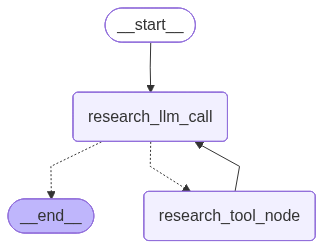

In [6]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [7]:
question = "How many words are in the sentence: 'LangGraph makes agents explicit and debuggable.'?"
result = graph.invoke({"messages": [HumanMessage(content=question)]})
for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

How many words are in the sentence: 'LangGraph makes agents explicit and debuggable.'?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'There are 6 words in that sentence.', 'extras': {'signature': 'ErAECq0EAQw51sfhTZmX2kqvpHyV+5cEjHNKmZu0DpWCB6R+u4gsck06vA3BK8b0pW9LofcG6SzsW6k2rObq2LfFJw8M0LX5bl0LPEMzefyNuEXZSL719NoVgF9s9o3lKNz1SELtSYtg0Zh1Pf5kDRBbgJNBZYLHhFBLHvfhOxuw0Z61CuZz4SsP1ef1XPcYRJ0GwZCcWlDBNuVn49rjZ2OsSfiYs8ql785qDjAv7AU8WZP35tN99JtpIIxa3IZYr0fakmqeQSnSVDDc9oOcuimEMPNAF2veaySX2wS61Itz8m/y50EbSw/VO0t4t9iBgxhq+oc20aJD+sAo87nuut2WiYDCyqHsBE2QEgUyZ6lSRenzpTr58aEXHSSPmIPEFkwXB1JeucTJ2MX6wh8mjVKuZiVAKFv03qRpQlT8DqdUgYhcNIBxaubA0+LUhfUDf2SBtF/CchXLUY6va6AmDFwQdCVf7L5MYaAAvuZWimq3v8peM+DbBEH5x1fegTHk9L631jISGvSDra5h8VE6HZvlbkU86A0nxLUAXxxWZEokpqBZmPWLV12g1ST9DtcUh1yLgjmNkOk09YnITKOieShxOfvJGY9pIYZj0V+78qtWx1hRzRdKmgxTVbnLNR790WJHDhI8WxgYMiKz/QD

## Takeaways

- An agent is **just two nodes in a loop**: `llm_call` ↔ `tool_node`.
- The LLM's `tool_calls` on the last message are the signal to loop or stop.
- `MessagesState` makes the conversation history the shared memory.
- More autonomy = more power, but also more tokens, more latency, and harder debugging.

## Try it yourself

- Build a math-tutor agent with tools `solve_equation`, `plot_graph` (stub it), and `explain_step`. Ask it: *"Solve x^2 - 5x + 6 = 0 and walk me through it."*

---

## Congratulations — you've covered all six patterns!

| Pattern | Control flow | Use when |
|---|---|---|
| Prompt Chaining | Fixed sequence | Ordered steps |
| Parallelization | Fixed fan-out | Independent sub-tasks |
| Routing | LLM picks one branch | Multiple specialists |
| Orchestrator–Worker | LLM plans N workers | Dynamic sub-tasks |
| Evaluator–Optimizer | Generate + grade loop | Iterative refinement |
| Agent | LLM in full control | Open-ended tool use |

Most real-world systems **combine** these — e.g. an agent that internally uses a router, or a chain whose last node is an evaluator. Start simple, only add complexity when a pattern genuinely fits.
